In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
housing = fetch_california_housing(as_frame=True)


X = housing.frame.drop('MedHouseVal',axis=1)
y = housing.frame['MedHouseVal'] #Target : median house value

In [30]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [12]:
X.shape

(20640, 8)

In [14]:
X.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=45)

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
#help(KNeighborsRegressor)

In [16]:
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_scaled,y_train)

KNeighborsRegressor()

In [17]:
y_pred = knn_reg.predict(X_test_scaled)

In [18]:
mean_absolute_error(y_test,y_pred)

0.44430533430232555

In [19]:
mean_squared_error(y_test,y_pred)

0.4174890927794089

In [20]:
np.sqrt(mean_squared_error(y_test,y_pred)) #rmse

np.float64(0.6461339588501821)

# Tune Hyperparameter

In [21]:
neighbors_range = range(1,31)
rmse_score = []

for n in neighbors_range:
  knn = KNeighborsRegressor(n_neighbors=n)
  knn.fit(X_train_scaled,y_train)

  y_pred = knn.predict(X_test_scaled)
  rmse_score.append(np.sqrt(mean_squared_error(y_test,y_pred)))

In [25]:
print(f"Optimal k Value: {np.argmin(rmse_score)} with minimum rmse of {np.min(rmse_score)}")

Optimal k Value: 11 with minimum rmse of 0.6384457183022735


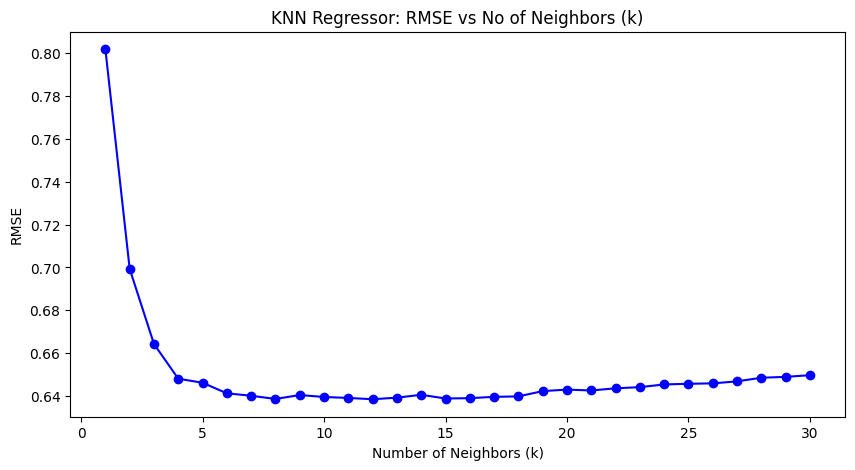

In [27]:
plt.figure(figsize=(10,5))
plt.plot(neighbors_range,rmse_score,marker='o',ls='-',color='blue')
plt.title('KNN Regressor: RMSE vs No of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('RMSE')
plt.show()

In [28]:
# Final Model

knn_final = KNeighborsRegressor(n_neighbors=6)
knn_final.fit(X_train_scaled,y_train)


y_pred_final = knn_final.predict(X_test_scaled)
np.sqrt(mean_squared_error(y_test,y_pred_final))

np.float64(0.6412079345030994)